In [1]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.metrics import accuracy_score, f1_score

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.0+cpu
Device: cpu


In [2]:
project_root = Path.cwd().parent

if not (project_root / "data").exists():
    project_root = Path.cwd().parent.parent

processed_dir = project_root / "data" / "processed"
image_root = project_root / "data" / "raw" / "PlantSeg" / "images"
checkpoint_dir = project_root / "models" / "checkpoints"

clean_metadata_path = (
    processed_dir / "agrisense_metadata_clean.csv"
)

print("Project root:", project_root)
print("Metadata exists:", clean_metadata_path.exists())
print("Image directory exists:", image_root.exists())

Project root: c:\Users\Dell\Documents\Projects\AgriSense
Metadata exists: True
Image directory exists: True


In [3]:
df_clean = pd.read_csv(clean_metadata_path)

disease_classes = sorted(
    df_clean["Disease"].unique()
)

disease_to_id = {
    disease: idx
    for idx, disease in enumerate(disease_classes)
}

id_to_disease = {
    idx: disease
    for disease, idx in disease_to_id.items()
}

df_clean["disease_id"] = (
    df_clean["Disease"].map(disease_to_id)
)

print("Dataset shape:", df_clean.shape)
print("Disease classes:", len(disease_classes))
print("Missing disease IDs:", df_clean["disease_id"].isna().sum())

Dataset shape: (7399, 12)
Disease classes: 115
Missing disease IDs: 0


In [4]:
image_files = list(image_root.rglob("*"))

image_lookup = {
    path.name: path
    for path in image_files
    if path.is_file()
}

df_clean["actual_image_path"] = (
    df_clean["Name"].map(image_lookup)
)

print(
    "Missing image paths:",
    df_clean["actual_image_path"].isna().sum()
)

Missing image paths: 0


In [5]:
train_df = df_clean[
    df_clean["Split"] == "Training"
].reset_index(drop=True)

val_df = df_clean[
    df_clean["Split"] == "Validation"
].reset_index(drop=True)

test_df = df_clean[
    df_clean["Split"] == "Test"
].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 5084
Validation: 811
Test: 1504


In [6]:
class ResizeWithPadding:
    def __init__(self, size):
        self.target_h, self.target_w = size

    def __call__(self, image):
        w, h = image.size

        scale = min(
            self.target_w / w,
            self.target_h / h
        )

        new_w = int(round(w * scale))
        new_h = int(round(h * scale))

        image = image.resize(
            (new_w, new_h),
            Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.target_w, self.target_h),
            (0, 0, 0)
        )

        left = (self.target_w - new_w) // 2
        top = (self.target_h - new_h) // 2

        canvas.paste(
            image,
            (left, top)
        )

        return canvas


train_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class AgriSenseClassificationDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["actual_image_path"]
        ).convert("RGB")

        label = int(row["disease_id"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
BATCH_SIZE = 16

train_dataset = AgriSenseClassificationDataset(
    train_df,
    transform=train_transform
)

val_dataset = AgriSenseClassificationDataset(
    val_df,
    transform=eval_transform
)

test_dataset = AgriSenseClassificationDataset(
    test_df,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 318
Validation batches: 51
Test batches: 94


In [9]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Seed:", SEED)

Device: cpu
Seed: 42


In [10]:
num_classes = len(disease_classes)

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Freeze entire backbone
for param in model.parameters():
    param.requires_grad = False

# Fine-tune Layer 4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11235507
Trainable parameters: 8452723


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Initial learning rate: 0.0001


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1

In [13]:
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

best_val_loss = float("inf")
best_val_macro_f1 = -float("inf")
best_epoch = 0
epochs_without_improvement = 0

history = []

best_checkpoint_path = checkpoint_dir / "resnet18_extended_finetuned_best.pth"
latest_checkpoint_path = checkpoint_dir / "resnet18_extended_finetuned_latest.pth"

print("Epochs:", NUM_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Best checkpoint:", best_checkpoint_path)

Epochs: 10
Early stopping patience: 3
Best checkpoint: c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_extended_finetuned_best.pth


In [14]:
from tqdm.auto import tqdm

for epoch in range(1, NUM_EPOCHS + 1):

    # Training

    model.train()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} - Training",
        unit="batch"
    )

    for images, labels in train_progress:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # Show current loss in progress bar
        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(all_labels, all_predictions)
    train_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    # Validation

    model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    val_progress = tqdm(
        val_loader,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} - Validation",
        unit="batch"
    )

    with torch.no_grad():

        for images, labels in val_progress:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

            val_progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss = running_loss / len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_predictions)
    val_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    current_lr = optimizer.param_groups[0]["lr"]

    # Save history

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_macro_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "learning_rate": current_lr
    })

    # Epoch summary

    print(
        f"\nEpoch {epoch}/{NUM_EPOCHS}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Train Acc: {train_acc:.2%}"
        f" | Train Macro F1: {train_macro_f1:.2%}"
        f" | Val Loss: {val_loss:.4f}"
        f" | Val Acc: {val_acc:.2%}"
        f" | Val Macro F1: {val_macro_f1:.2%}"
        f" | LR: {current_lr:.6f}"
    )

    # Save latest checkpoint

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
    }, latest_checkpoint_path)

    # Save best checkpoint

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_macro_f1": val_macro_f1,
        }, best_checkpoint_path)

        print("✓ Best checkpoint updated.")

    else:
        epochs_without_improvement += 1

    # Learning-rate scheduler

    scheduler.step(val_loss)

    # Early stopping

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print(
            f"\nEarly stopping triggered after "
            f"{epoch} epochs."
        )

        break

c:\Users\Dell\Documents\Projects\AgriSense\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 1/10 - Validation: 100%|██████████| 51/51 [00:54<00:00,  1.07s/batch, loss=3.4690]



Epoch 1/10 | Train Loss: 3.4199 | Train Acc: 24.88% | Train Macro F1: 11.30% | Val Loss: 2.5134 | Val Acc: 42.79% | Val Macro F1: 22.07% | LR: 0.000100
✓ Best checkpoint updated.


Epoch 2/10 - Validation: 100%|██████████| 51/51 [00:54<00:00,  1.07s/batch, loss=2.9162]



Epoch 2/10 | Train Loss: 2.1909 | Train Acc: 48.78% | Train Macro F1: 31.51% | Val Loss: 2.0006 | Val Acc: 49.82% | Val Macro F1: 31.65% | LR: 0.000100
✓ Best checkpoint updated.


Epoch 3/10 - Validation: 100%|██████████| 51/51 [00:54<00:00,  1.07s/batch, loss=2.8046]


...


Epoch 8/10 | Train Loss: 0.4478 | Train Acc: 91.56% | Train Macro F1: 87.52% | Val Loss: 1.4968 | Val Acc: 58.82% | Val Macro F1: 45.84% | LR: 0.000100


Epoch 9/10 - Validation: 100%|██████████| 51/51 [00:51<00:00,  1.02s/batch, loss=2.4325]



Epoch 9/10 | Train Loss: 0.3484 | Train Acc: 93.41% | Train Macro F1: 90.12% | Val Loss: 1.5772 | Val Acc: 58.94% | Val Macro F1: 45.56% | LR: 0.000100


Epoch 10/10 - Validation: 100%|██████████| 51/51 [00:51<00:00,  1.01s/batch, loss=2.2936]


Epoch 10/10 | Train Loss: 0.2386 | Train Acc: 96.54% | Train Macro F1: 95.07% | Val Loss: 1.4752 | Val Acc: 62.15% | Val Macro F1: 49.56% | LR: 0.000050

Early stopping triggered after 10 epochs.


In [14]:
history_df = pd.DataFrame(history)

display(history_df)

""


In [15]:
# Check the current history_df structure

print("history_df type:", type(history_df))
print("history_df shape:", history_df.shape)
print("history_df columns:", history_df.columns.tolist())

display(history_df.head())

history_df type: <class 'pandas.DataFrame'>
history_df shape: (0, 0)
history_df columns: []


""


In [16]:
# Reconstruct Training History

history_df = pd.DataFrame({
    "epoch": list(range(1, 11)),

    "train_loss": [
        3.4199, 2.1909, 1.6350, 1.2627, 0.9762,
        0.7594, 0.5645, 0.4478, 0.3484, 0.2386
    ],

    "train_accuracy": [
        0.2488, 0.4878, 0.6115, 0.7008, 0.7791,
        0.8352, 0.8904, 0.9156, 0.9341, 0.9654
    ],

    "train_macro_f1": [
        0.1130, 0.3151, 0.4655, 0.5842, 0.6817,
        0.7554, 0.8294, 0.8752, 0.9012, 0.9507
    ],

    "val_loss": [
        2.5134, 2.0006, 1.7243, 1.6314, 1.5742,
        1.5024, 1.4635, 1.4968, 1.5772, 1.4752
    ],

    "val_accuracy": [
        0.4279, 0.4982, 0.5413, 0.5573, 0.5573,
        0.5968, 0.6017, 0.5882, 0.5894, 0.6215
    ],

    "val_macro_f1": [
        0.2207, 0.3165, 0.3740, 0.3968, 0.4054,
        0.4600, 0.4706, 0.4584, 0.4556, 0.4956
    ],

    "learning_rate": [
        0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
        0.0001, 0.0001, 0.0001, 0.0001, 0.00005
    ]
})

display(history_df)

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,learning_rate
0,1,3.4199,0.2488,0.1130,2.5134,0.4279,0.2207,0.00010
1,2,2.1909,0.4878,0.3151,2.0006,0.4982,0.3165,0.00010
2,3,1.6350,0.6115,0.4655,1.7243,0.5413,0.3740,0.00010
3,4,1.2627,0.7008,0.5842,1.6314,0.5573,0.3968,0.00010
4,5,0.9762,0.7791,0.6817,1.5742,0.5573,0.4054,0.00010
5,6,0.7594,0.8352,0.7554,1.5024,0.5968,0.4600,0.00010
6,7,0.5645,0.8904,0.8294,1.4635,0.6017,0.4706,0.00010
7,8,0.4478,0.9156,0.8752,1.4968,0.5882,0.4584,0.00010
8,9,0.3484,0.9341,0.9012,1.5772,0.5894,0.4556,0.00010
9,10,0.2386,0.9654,0.9507,1.4752,0.6215,0.4956,0.00005


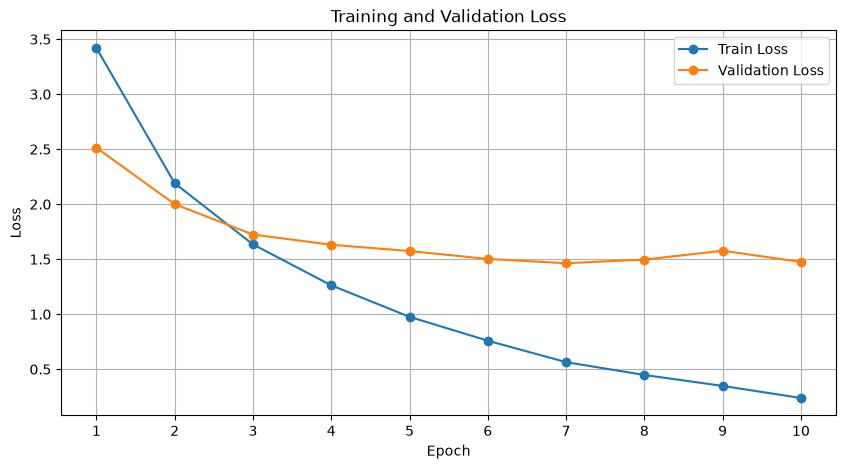

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)

plt.show()

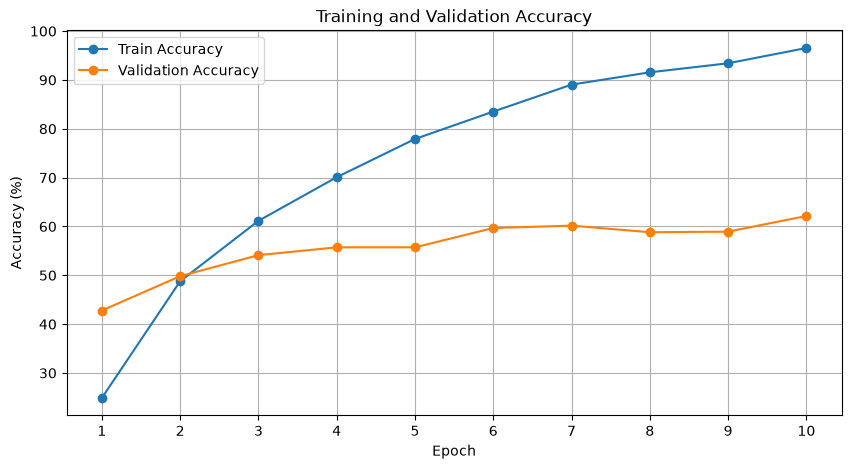

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"] * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)

plt.show()

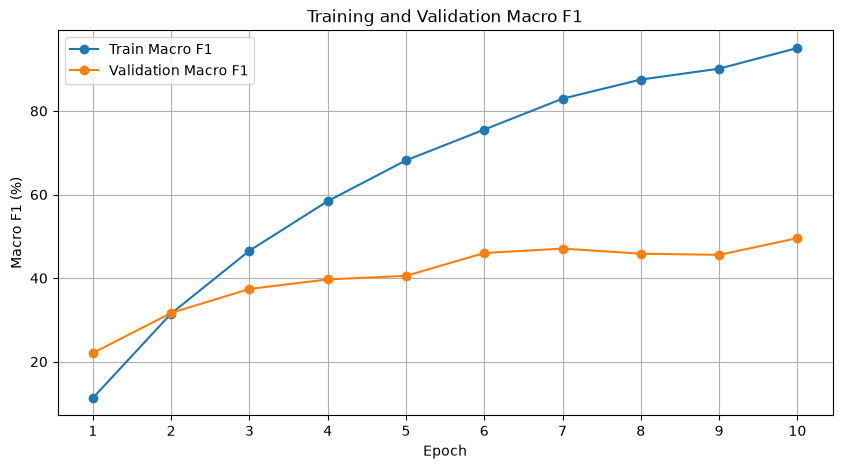

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"] * 100,
    marker="o",
    label="Train Macro F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"] * 100,
    marker="o",
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 (%)")
plt.title("Training and Validation Macro F1")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)

plt.show()

In [20]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Best checkpoint loaded")
print("Epoch:", best_checkpoint["epoch"])
print("Validation Loss:", best_checkpoint["val_loss"])
print("Validation Accuracy:", f"{best_checkpoint['val_accuracy']:.2%}")
print("Validation Macro F1:", f"{best_checkpoint['val_macro_f1']:.2%}")

Best checkpoint loaded
Epoch: 7
Validation Loss: 1.4635048474101338
Validation Accuracy: 60.17%
Validation Macro F1: 47.06%


In [21]:
# Final Test Evaluation

test_loss, test_accuracy, test_macro_f1 = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\nExtended Fine-Tuning — Test Results")
print("-----------------------------------")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2%}")
print("Test Macro F1:", f"{test_macro_f1:.2%}")


Extended Fine-Tuning — Test Results
-----------------------------------
Test Loss: 1.4485
Test Accuracy: 60.97%
Test Macro F1: 50.19%


In [22]:
model.eval()

all_test_labels = []
all_test_predictions = []

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Final Test Evaluation",
        unit="batch"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_predictions.extend(predictions.cpu().numpy())

test_weighted_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="weighted",
    zero_division=0
)

print("Test Weighted F1:", f"{test_weighted_f1:.2%}")

Final Test Evaluation: 100%|██████████| 94/94 [02:07<00:00,  1.36s/batch]

Test Weighted F1: 59.35%


In [23]:
baseline_accuracy = 0.5944
baseline_macro_f1 = 0.4650
baseline_weighted_f1 = 0.5779

print("Model Comparison")
print("=" * 60)

print(f"{'Metric':<25} {'Notebook 06':>15} {'Notebook 10':>15}")
print("-" * 60)

print(
    f"{'Test Accuracy':<25}"
    f"{baseline_accuracy:>14.2%}"
    f"{test_accuracy:>15.2%}"
)

print(
    f"{'Test Macro F1':<25}"
    f"{baseline_macro_f1:>14.2%}"
    f"{test_macro_f1:>15.2%}"
)

print(
    f"{'Test Weighted F1':<25}"
    f"{baseline_weighted_f1:>14.2%}"
    f"{test_weighted_f1:>15.2%}"
)

print("-" * 60)

print(
    f"{'Accuracy Change':<25}"
    f"{test_accuracy - baseline_accuracy:>15.2%}"
)

print(
    f"{'Macro F1 Change':<25}"
    f"{test_macro_f1 - baseline_macro_f1:>15.2%}"
)

print(
    f"{'Weighted F1 Change':<25}"
    f"{test_weighted_f1 - baseline_weighted_f1:>15.2%}"
)

Model Comparison
Metric                        Notebook 06     Notebook 10
------------------------------------------------------------
Test Accuracy                    59.44%         60.97%
Test Macro F1                    46.50%         50.19%
Test Weighted F1                 57.79%         59.35%
------------------------------------------------------------
Accuracy Change                    1.53%
Macro F1 Change                    3.69%
Weighted F1 Change                 1.56%


In [24]:
from sklearn.metrics import classification_report

all_class_ids = list(range(len(disease_classes)))

report = classification_report(
    all_test_labels,
    all_test_predictions,
    labels=all_class_ids,
    target_names=disease_classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

display(
    report_df.iloc[:len(disease_classes)]
    .sort_values("f1-score", ascending=False)
    .head(20)
)

,precision,recall,f1-score,support
raspberry gray mold,1.000000,1.000000,1.000000,2.0
carrot cavity spot,1.000000,0.888889,0.941176,9.0
banana bunchy top,0.866667,1.000000,0.928571,13.0
banana black leaf streak,0.954545,0.875000,0.913043,24.0
bell pepper blossom end rot,0.875000,0.875000,0.875000,16.0
wheat stem rust,0.900000,0.818182,0.857143,22.0
corn smut,0.821429,0.884615,0.851852,26.0
basil downy mildew,0.888889,0.800000,0.842105,10.0
cabbage black rot,0.842105,0.842105,0.842105,19.0
citrus greening disease,0.739130,0.944444,0.829268,18.0


In [25]:
display(
    report_df.iloc[:len(disease_classes)]
    .sort_values("f1-score")
    .head(20)
)

,precision,recall,f1-score,support
bean mosaic virus,0.000000,0.000000,0.000000,9.0
cabbage alternaria leaf spot,0.000000,0.000000,0.000000,6.0
blueberry botrytis blight,0.000000,0.000000,0.000000,3.0
bell pepper frogeye leaf spot,0.000000,0.000000,0.000000,4.0
broccoli ring spot,0.000000,0.000000,0.000000,1.0
celery anthracnose,0.000000,0.000000,0.000000,3.0
cauliflower bacterial soft rot,0.000000,0.000000,0.000000,4.0
cauliflower alternaria leaf spot,0.000000,0.000000,0.000000,2.0
coffee black rot,0.000000,0.000000,0.000000,0.0
coffee brown eye spot,0.000000,0.000000,0.000000,2.0


In [26]:
#F1 by training-support group

train_support = (
    train_df["disease_id"]
    .value_counts()
    .reindex(range(len(disease_classes)), fill_value=0)
)

test_f1 = report_df.iloc[:len(disease_classes)]["f1-score"].values

support_analysis = pd.DataFrame({
    "disease_id": range(len(disease_classes)),
    "disease": disease_classes,
    "train_support": train_support.values,
    "test_f1": test_f1
})

def support_group(n):
    if n <= 5:
        return "1-5"
    elif n <= 10:
        return "6-10"
    elif n <= 20:
        return "11-20"
    elif n <= 50:
        return "21-50"
    else:
        return "51+"

support_analysis["support_group"] = (
    support_analysis["train_support"]
    .apply(support_group)
)

group_summary = (
    support_analysis
    .groupby("support_group")["test_f1"]
    .agg(["count", "mean", "median"])
    .reindex(["1-5", "6-10", "11-20", "21-50", "51+"])
)

display(group_summary)

,count,mean,median
support_group,,,
1-5,3,0.000000,0.000000
6-10,5,0.133333,0.000000
11-20,26,0.397523,0.472222
21-50,41,0.507818,0.500000
51+,40,0.634710,0.660606


In [27]:
# See the worst-performing diseases with their training support

display(
    support_analysis
    .sort_values("test_f1")
    [["disease", "train_support", "test_f1"]]
    .head(25)
)

,disease,train_support,test_f1
12,bean mosaic virus,20,0.000000
26,cabbage alternaria leaf spot,19,0.000000
19,blueberry botrytis blight,13,0.000000
16,bell pepper frogeye leaf spot,11,0.000000
25,broccoli ring spot,5,0.000000
34,celery anthracnose,7,0.000000
33,cauliflower bacterial soft rot,11,0.000000
32,cauliflower alternaria leaf spot,18,0.000000
41,coffee black rot,2,0.000000
42,coffee brown eye spot,7,0.000000


In [28]:
#Top-1 and Top-5 Accuracy

model.eval()

top1_correct = 0
top5_correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Calculating Top-5 Accuracy"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Top-5 predicted classes
        _, top5_predictions = outputs.topk(5, dim=1)

        # Top-1
        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        # Top-5
        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

        total += labels.size(0)

top1_accuracy = top1_correct / total
top5_accuracy = top5_correct / total

print(f"Top-1 Accuracy: {top1_accuracy:.2%}")
print(f"Top-5 Accuracy: {top5_accuracy:.2%}")

Calculating Top-5 Accuracy: 100%|██████████| 94/94 [02:06<00:00,  1.35s/it]

Top-1 Accuracy: 60.97%
Top-5 Accuracy: 87.83%


In [29]:
# Confusion Matrix Data

from sklearn.metrics import confusion_matrix

model.eval()

all_test_labels = []
all_test_predictions = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting Test Predictions"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_predictions.extend(predictions.cpu().numpy())

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions,
    labels=list(range(len(disease_classes)))
)

print("Confusion matrix shape:", cm.shape)
print("Total test samples:", cm.sum())

Confusion matrix shape: (115, 115)
Total test samples: 1504


In [30]:
#Most Frequent Disease Confusions

confusion_pairs = []

for true_id in range(len(disease_classes)):
    for pred_id in range(len(disease_classes)):
        if true_id != pred_id and cm[true_id, pred_id] > 0:
            confusion_pairs.append({
                "true_disease": disease_classes[true_id],
                "predicted_disease": disease_classes[pred_id],
                "count": cm[true_id, pred_id]
            })

confusion_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(confusion_df.head(20))

,true_disease,predicted_disease,count
0,squash powdery mildew,zucchini powdery mildew,14
1,garlic rust,wheat leaf rust,8
2,cucumber powdery mildew,squash powdery mildew,7
3,ginger sheath blight,rice sheath blight,6
4,zucchini powdery mildew,squash powdery mildew,6
5,wheat septoria blotch,wheat powdery mildew,5
6,tomato yellow leaf curl virus,tomato mosaic virus,5
7,zucchini bacterial wilt,cucumber bacterial wilt,5
8,corn gray leaf spot,corn northern leaf blight,4
9,wheat stripe rust,wheat powdery mildew,4


In [31]:
#Same-Plant vs Cross-Plant Errors

# Map each disease to its plant
disease_to_plant = (
    df_clean[["Disease", "Plant"]]
    .drop_duplicates("Disease")
    .set_index("Disease")["Plant"]
    .to_dict()
)

error_rows = []

for true_id, pred_id in zip(all_test_labels, all_test_predictions):

    if true_id == pred_id:
        continue

    true_disease = disease_classes[true_id]
    predicted_disease = disease_classes[pred_id]

    true_plant = disease_to_plant[true_disease]
    predicted_plant = disease_to_plant[predicted_disease]

    error_rows.append({
        "true_disease": true_disease,
        "predicted_disease": predicted_disease,
        "true_plant": true_plant,
        "predicted_plant": predicted_plant,
        "same_plant": true_plant == predicted_plant
    })

error_analysis_df = pd.DataFrame(error_rows)

same_plant_errors = error_analysis_df["same_plant"].sum()
cross_plant_errors = (~error_analysis_df["same_plant"]).sum()
total_errors = len(error_analysis_df)

print(f"Total incorrect predictions: {total_errors}")
print(f"Same-plant errors: {same_plant_errors}")
print(f"Cross-plant errors: {cross_plant_errors}")

print(
    f"Same-plant error percentage: "
    f"{same_plant_errors / total_errors:.2%}"
)

print(
    f"Cross-plant error percentage: "
    f"{cross_plant_errors / total_errors:.2%}"
)

Total incorrect predictions: 587
Same-plant errors: 170
Cross-plant errors: 417
Same-plant error percentage: 28.96%
Cross-plant error percentage: 71.04%


In [32]:
# Evaluate Latest Checkpoint on Validation

latest_checkpoint_path = project_root / "models" / "checkpoints" / "resnet18_extended_finetuned_latest.pth"

print("Checkpoint:", latest_checkpoint_path)
print("Exists:", latest_checkpoint_path.exists())

checkpoint = torch.load(
    latest_checkpoint_path,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

val_loss_latest = 0.0
val_correct_latest = 0
val_total_latest = 0

val_labels_latest = []
val_predictions_latest = []

with torch.no_grad():
    for images, labels in tqdm(
        val_loader,
        desc="Evaluating latest checkpoint"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss_latest += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        val_correct_latest += (
            predictions == labels
        ).sum().item()

        val_total_latest += labels.size(0)

        val_labels_latest.extend(labels.cpu().numpy())
        val_predictions_latest.extend(predictions.cpu().numpy())

val_loss_latest /= val_total_latest
val_accuracy_latest = val_correct_latest / val_total_latest

val_macro_f1_latest = f1_score(
    val_labels_latest,
    val_predictions_latest,
    average="macro",
    zero_division=0
)

val_weighted_f1_latest = f1_score(
    val_labels_latest,
    val_predictions_latest,
    average="weighted",
    zero_division=0
)

print(f"Latest checkpoint validation loss: {val_loss_latest:.4f}")
print(f"Latest checkpoint validation accuracy: {val_accuracy_latest:.2%}")
print(f"Latest checkpoint validation Macro F1: {val_macro_f1_latest:.2%}")
print(f"Latest checkpoint validation Weighted F1: {val_weighted_f1_latest:.2%}")

Checkpoint: c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_extended_finetuned_latest.pth
Exists: True


Evaluating latest checkpoint: 100%|██████████| 51/51 [01:00<00:00,  1.19s/it]

Latest checkpoint validation loss: 1.4752
Latest checkpoint validation accuracy: 62.15%
Latest checkpoint validation Macro F1: 49.56%
Latest checkpoint validation Weighted F1: 60.74%


In [33]:
#Final Checkpoint Selection

final_checkpoint_path = latest_checkpoint_path

selection_reason = """
Selected using validation performance rather than test performance.
Epoch 10 achieved the highest validation accuracy and Macro F1 among
the evaluated checkpoints, while Epoch 7 achieved the lowest validation loss.
Because this is a 115-class imbalanced disease classification problem,
Macro F1 is used as an important model-selection metric.
"""

print("Final classifier checkpoint:")
print(final_checkpoint_path)

print("\nSelection criterion:")
print(selection_reason)

print("Validation metrics:")
print(f"Accuracy:     {val_accuracy_latest:.2%}")
print(f"Macro F1:     {val_macro_f1_latest:.2%}")
print(f"Weighted F1:  {val_weighted_f1_latest:.2%}")
print(f"Loss:         {val_loss_latest:.4f}")

Final classifier checkpoint:
c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_extended_finetuned_latest.pth

Selection criterion:

Selected using validation performance rather than test performance.
Epoch 10 achieved the highest validation accuracy and Macro F1 among
the evaluated checkpoints, while Epoch 7 achieved the lowest validation loss.
Because this is a 115-class imbalanced disease classification problem,
Macro F1 is used as an important model-selection metric.

Validation metrics:
Accuracy:     62.15%
Macro F1:     49.56%
Weighted F1:  60.74%
Loss:         1.4752


In [34]:
# Final Test Evaluation

# Loading the selected final classifier
checkpoint = torch.load(
    final_checkpoint_path,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

final_test_loss = 0.0
final_test_correct = 0
final_test_total = 0

final_test_labels = []
final_test_predictions = []

with torch.no_grad():
    for images, labels in tqdm(
        test_loader,
        desc="Final Test Evaluation"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        final_test_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        final_test_correct += (
            predictions == labels
        ).sum().item()

        final_test_total += labels.size(0)

        final_test_labels.extend(labels.cpu().numpy())
        final_test_predictions.extend(predictions.cpu().numpy())

final_test_loss /= final_test_total
final_test_accuracy = final_test_correct / final_test_total

final_test_macro_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    average="macro",
    zero_division=0
)

final_test_weighted_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    average="weighted",
    zero_division=0
)

print("\nFINAL CLASSIFIER TEST RESULTS")
print("-" * 40)
print(f"Test Loss:        {final_test_loss:.4f}")
print(f"Test Accuracy:    {final_test_accuracy:.2%}")
print(f"Test Macro F1:    {final_test_macro_f1:.2%}")
print(f"Test Weighted F1: {final_test_weighted_f1:.2%}")

Final Test Evaluation: 100%|██████████| 94/94 [01:51<00:00,  1.19s/it]


FINAL CLASSIFIER TEST RESULTS
----------------------------------------
Test Loss:        1.4396
Test Accuracy:    62.70%
Test Macro F1:    51.48%
Test Weighted F1: 61.24%


In [35]:
# Final Top-5 Accuracy

model.eval()

final_top1_correct = 0
final_top5_correct = 0
final_total = 0

with torch.no_grad():
    for images, labels in tqdm(
        test_loader,
        desc="Final Top-5 Evaluation"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, top5_predictions = outputs.topk(5, dim=1)

        final_top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        final_top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

        final_total += labels.size(0)

final_top1_accuracy = final_top1_correct / final_total
final_top5_accuracy = final_top5_correct / final_total

print(f"Final Top-1 Accuracy: {final_top1_accuracy:.2%}")
print(f"Final Top-5 Accuracy: {final_top5_accuracy:.2%}")

Final Top-5 Evaluation: 100%|██████████| 94/94 [01:57<00:00,  1.25s/it]

Final Top-1 Accuracy: 62.70%
Final Top-5 Accuracy: 88.50%


In [36]:
# Final Model Predictions for Error Analysis

model.eval()

final_labels = []
final_predictions = []

with torch.no_grad():
    for images, labels in tqdm(
        test_loader,
        desc="Collecting Final Predictions"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        final_labels.extend(labels.cpu().numpy())
        final_predictions.extend(predictions.cpu().numpy())

print(f"Total test predictions: {len(final_labels)}")

Total test predictions: 1504


In [37]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(
    final_labels,
    final_predictions,
    labels=list(range(len(disease_classes)))
)

print("Confusion matrix shape:", final_cm.shape)
print("Total samples:", final_cm.sum())

Confusion matrix shape: (115, 115)
Total samples: 1504


In [38]:
final_confusion_pairs = []

for true_id in range(len(disease_classes)):
    for pred_id in range(len(disease_classes)):
        if true_id != pred_id and final_cm[true_id, pred_id] > 0:
            final_confusion_pairs.append({
                "true_disease": disease_classes[true_id],
                "predicted_disease": disease_classes[pred_id],
                "count": final_cm[true_id, pred_id]
            })

final_confusion_df = (
    pd.DataFrame(final_confusion_pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(final_confusion_df.head(20))

,true_disease,predicted_disease,count
0,squash powdery mildew,zucchini powdery mildew,14
1,zucchini powdery mildew,squash powdery mildew,8
2,ginger sheath blight,rice sheath blight,7
3,cucumber powdery mildew,squash powdery mildew,6
4,wheat leaf rust,wheat stripe rust,5
5,tomato bacterial leaf spot,tomato septoria leaf spot,5
6,bean mosaic virus,soybean mosaic,5
7,tomato septoria leaf spot,tomato early blight,4
8,soybean frog eye leaf spot,bean rust,4
9,apple scab,apple rust,4


In [39]:
final_error_indices = [
    i for i, (true_id, pred_id)
    in enumerate(zip(final_labels, final_predictions))
    if true_id != pred_id
]

same_plant_errors = 0
cross_plant_errors = 0

for i in final_error_indices:
    true_disease = disease_classes[final_labels[i]]
    predicted_disease = disease_classes[final_predictions[i]]

    true_plant = df_clean.loc[
        df_clean["disease_id"] == final_labels[i], "Plant"
    ].iloc[0]

    predicted_plant = df_clean.loc[
        df_clean["disease_id"] == final_predictions[i], "Plant"
    ].iloc[0]

    if true_plant == predicted_plant:
        same_plant_errors += 1
    else:
        cross_plant_errors += 1

total_errors = len(final_error_indices)

print("Total incorrect predictions:", total_errors)
print(
    f"Same-plant errors: {same_plant_errors} "
    f"({same_plant_errors / total_errors * 100:.2f}%)"
)
print(
    f"Cross-plant errors: {cross_plant_errors} "
    f"({cross_plant_errors / total_errors * 100:.2f}%)"
)

Total incorrect predictions: 561
Same-plant errors: 153 (27.27%)
Cross-plant errors: 408 (72.73%)


In [40]:
from sklearn.metrics import classification_report

final_report = classification_report(
    final_labels,
    final_predictions,
    labels=list(range(len(disease_classes))),
    target_names=disease_classes,
    output_dict=True,
    zero_division=0
)

final_per_class_df = (
    pd.DataFrame(final_report)
    .T
    .reset_index()
    .rename(columns={"index": "disease"})
)

# Remove aggregate rows
final_per_class_df = final_per_class_df[
    ~final_per_class_df["disease"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

final_per_class_df = final_per_class_df.sort_values(
    "f1-score",
    ascending=True
).reset_index(drop=True)

display(final_per_class_df.head(20))

,disease,precision,recall,f1-score,support
0,bean mosaic virus,0.000000,0.000000,0.000000,9.0
1,cabbage alternaria leaf spot,0.000000,0.000000,0.000000,6.0
2,broccoli ring spot,0.000000,0.000000,0.000000,1.0
3,bell pepper frogeye leaf spot,0.000000,0.000000,0.000000,4.0
4,coffee black rot,0.000000,0.000000,0.000000,0.0
5,celery anthracnose,0.000000,0.000000,0.000000,3.0
6,cauliflower bacterial soft rot,0.000000,0.000000,0.000000,4.0
7,cauliflower alternaria leaf spot,0.000000,0.000000,0.000000,2.0
8,coffee brown eye spot,0.000000,0.000000,0.000000,2.0
9,zucchini downy mildew,0.000000,0.000000,0.000000,5.0


In [41]:
# Training support for each disease
train_support = (
    df_clean[df_clean["Split"] == "Training"]
    .groupby("Disease")
    .size()
    .rename("train_support")
)

# Combine with final per-disease performance
final_support_df = final_per_class_df.merge(
    train_support,
    left_on="disease",
    right_index=True,
    how="left"
)

display(
    final_support_df[
        ["disease", "train_support", "support", "f1-score"]
    ].sort_values("train_support")
)

,disease,train_support,support,f1-score
4,coffee black rot,2,0.0,0.000000
14,peach rust,4,1.0,0.000000
2,broccoli ring spot,5,1.0,0.000000
15,plum bacterial spot,6,3.0,0.000000
78,peach anthracnose,6,2.0,0.666667
...,...,...,...,...
93,wheat powdery mildew,116,35.0,0.777778
109,wheat head scab,133,43.0,0.857143
82,grape downy mildew,145,42.0,0.693069
98,wheat stripe rust,145,42.0,0.792079


In [42]:
pearson_support_f1 = final_support_df["train_support"].corr(
    final_support_df["f1-score"],
    method="pearson"
)

spearman_support_f1 = final_support_df["train_support"].corr(
    final_support_df["f1-score"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_support_f1:.3f}")
print(f"Spearman correlation: {spearman_support_f1:.3f}")

Pearson correlation: 0.468
Spearman correlation: 0.488


## Final Model Optimization — Conclusion

The final AgriSense disease classification model uses an ImageNet-pretrained ResNet18 with the final convolutional block (`layer4`) and classification head fine-tuned on the cleaned PlantSeg dataset.

The model was trained using a batch size of 16 for up to 10 epochs with Adam optimization at an initial learning rate of 0.0001. A `ReduceLROnPlateau` scheduler was used to reduce the learning rate when validation loss stopped improving. Model selection was based only on validation performance, with Macro F1 given particular importance because the dataset contains 115 disease classes with substantial class imbalance.

### Final Test Performance

- Test Accuracy: **62.70%**
- Test Macro F1: **51.48%**
- Test Weighted F1: **61.24%**
- Top-5 Accuracy: **88.50%**
- Test samples: **1,504**
- Disease classes: **115**

Compared with the frozen-backbone ResNet18 baseline:

- Accuracy improved from **44.02% to 62.70%** (+18.68 percentage points)
- Macro F1 improved from **33.99% to 51.48%** (+17.49 percentage points)
- Weighted F1 improved from **42.37% to 61.24%** (+18.87 percentage points)

### Error Analysis

The final model produced 561 incorrect predictions. Of these, 153 (27.27%) were same-plant errors and 408 (72.73%) were cross-plant errors.

The largest confusion patterns were primarily between visually similar diseases, including powdery mildew across related crops, rust diseases, and visually similar diseases affecting tomato, wheat, and other crops.

### Class Support Analysis

Training-set support showed a moderate positive relationship with final disease-level F1:

- Pearson correlation: **0.468**
- Spearman correlation: **0.488**

This indicates that training support contributes to disease-level performance, but it is not the only factor. Visual similarity between diseases and disease-specific complexity also affect classification performance.

Several low-support diseases achieved very low or zero F1, while some low-support classes still achieved reasonable performance. Therefore, additional data and improved representation of rare diseases remain important opportunities for future improvement.

### Final Model Selection

The epoch-10 checkpoint was selected using validation performance rather than test performance. It achieved the highest validation accuracy and Macro F1 among the trained checkpoints, while the epoch-7 checkpoint achieved the lowest validation loss.

The final selected checkpoint is:

`models/checkpoints/resnet18_extended_finetuned_latest.pth`

This model will be used as the final disease classification component of the AgriSense system.